###  Setup – Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 5)


df = pd.read_csv(r"D:\DAB303\cardekho_dataset.csv")   
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


## Understand the Shape & Data Types

In [3]:
print("Rows, Columns:", df.shape)
df.info()

Rows, Columns: (15411, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [4]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


### Check Missing Values & Duplicates

In [5]:
df.isnull().sum()
df.isnull().mean() * 100
df.duplicated().sum()

np.int64(0)

In [6]:
df.columns

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')

In [7]:
df = df.drop_duplicates()

In [8]:
df = df.dropna()

### Clean & Transform Key Columns

In [9]:
brands = [
    "Maruti Suzuki", "Maruti", "Hyundai", "Honda", "Toyota", "Ford",
    "Tata", "Mahindra", "Renault", "Chevrolet", "Volkswagen", "BMW",
    "Audi", "Mercedes Benz", "Land Rover", "Jaguar", "Nissan", "Skoda",
    "Jeep", "Kia", "MG", "Datsun", "Lexus", "Volvo", "Fiat"
]

def extract_brand(name):
    for b in brands:
        if name.lower().startswith(b.lower()):
            return b
    return name.split()[0]

df['brand'] = df['car_name'].apply(extract_brand)

In [10]:
df[['selling_price', 'km_driven']].dtypes

selling_price    int64
km_driven        int64
dtype: object

In [11]:
df[['selling_price', 'km_driven']] = df[['selling_price', 'km_driven']].astype(float)
df.dtypes

Unnamed: 0             int64
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven            float64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price        float64
dtype: object

In [12]:
df['year'] = 2024 - df['vehicle_age']
df = df[df['year'] >= 2000]

### Univariate Analysis

Numeric Variables – Histograms

In [13]:
df_plot = df.copy()

for col in ['selling_price', 'km_driven']:
    upper_limit = df_plot[col].quantile(0.99)
    df_plot[col] = df_plot[col].clip(upper=upper_limit)

C:\Users\HP\AppData\Local\Temp\ipykernel_8536\1836552633.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(formatted)


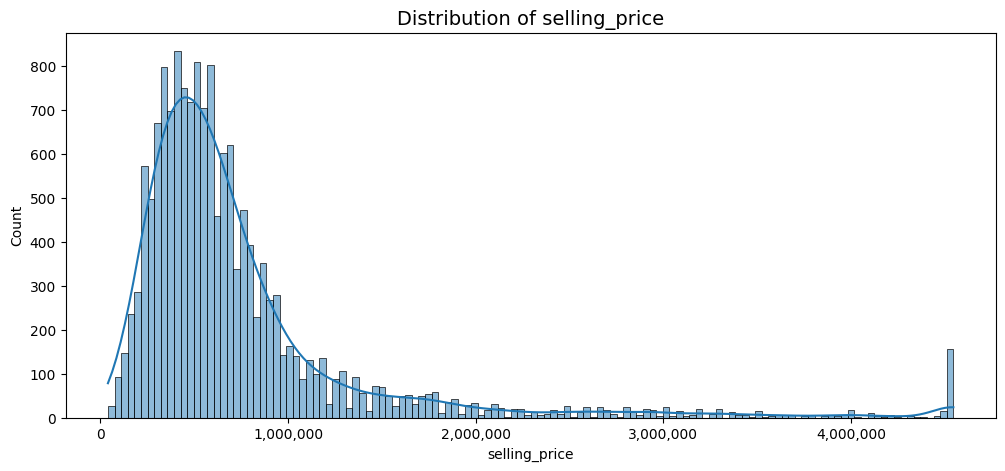

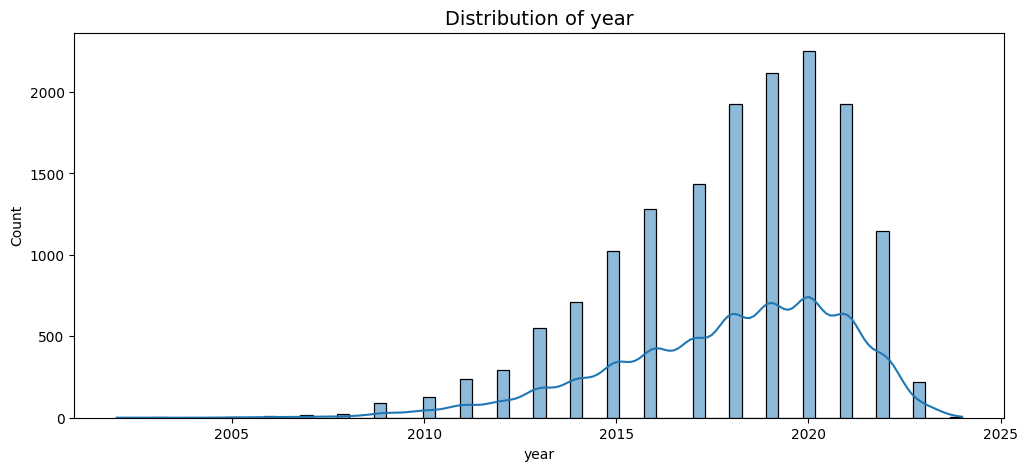

C:\Users\HP\AppData\Local\Temp\ipykernel_8536\1836552633.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(formatted)


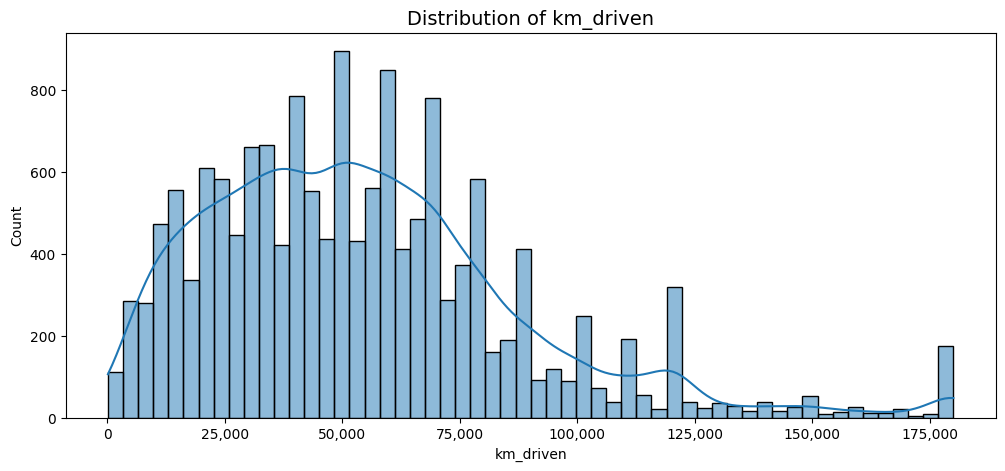

In [34]:
numeric_cols = ['selling_price', 'year', 'km_driven']

for col in numeric_cols:
    plt.figure(figsize=(12,5))
    ax = sns.histplot(df_plot[col], kde=True)
    plt.title(f"Distribution of {col}", fontsize=14)

    if col in ['selling_price', 'km_driven']:
        ticks = ax.get_xticks()                     
        formatted = [f"{int(t):,}" for t in ticks]  
        ax.set_xticklabels(formatted)               
    
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

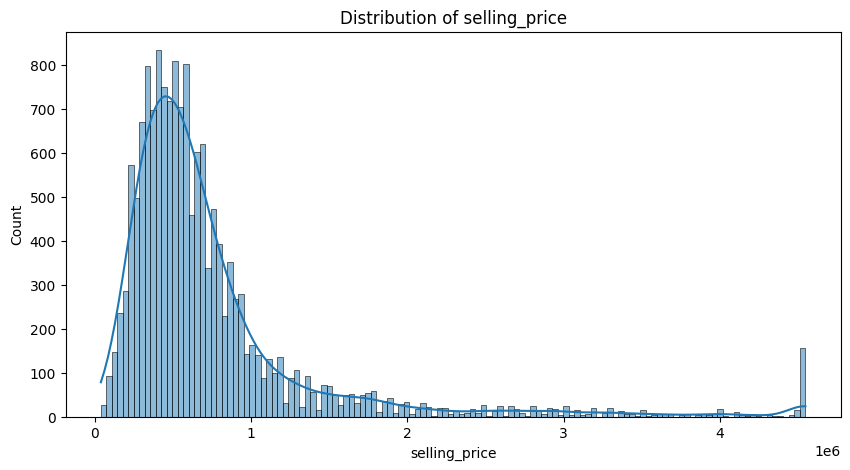

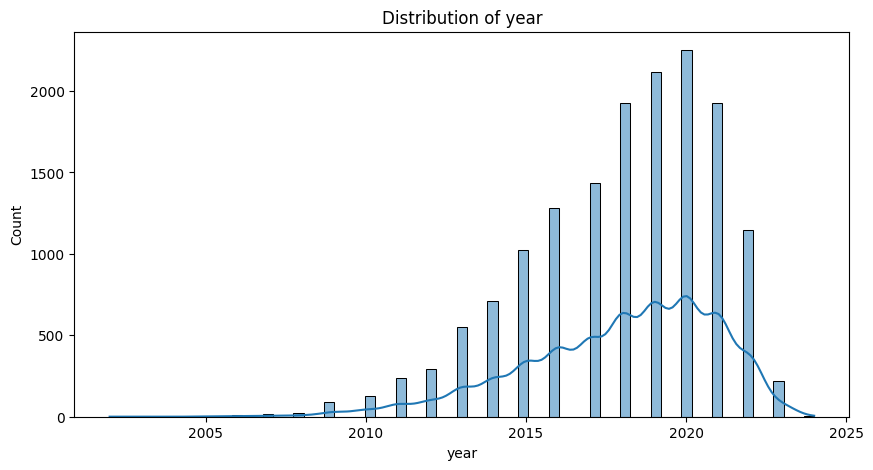

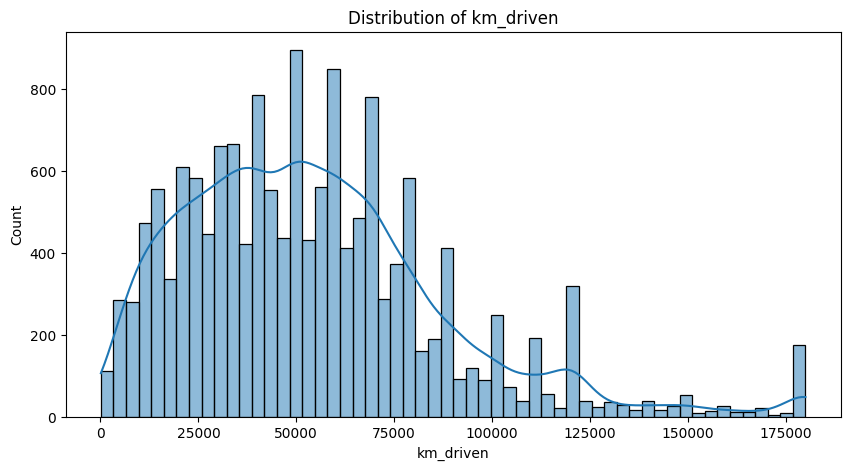

In [16]:
numeric_cols = ['selling_price', 'year', 'km_driven']

for col in numeric_cols:
    plt.figure()
    sns.histplot(df_plot[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

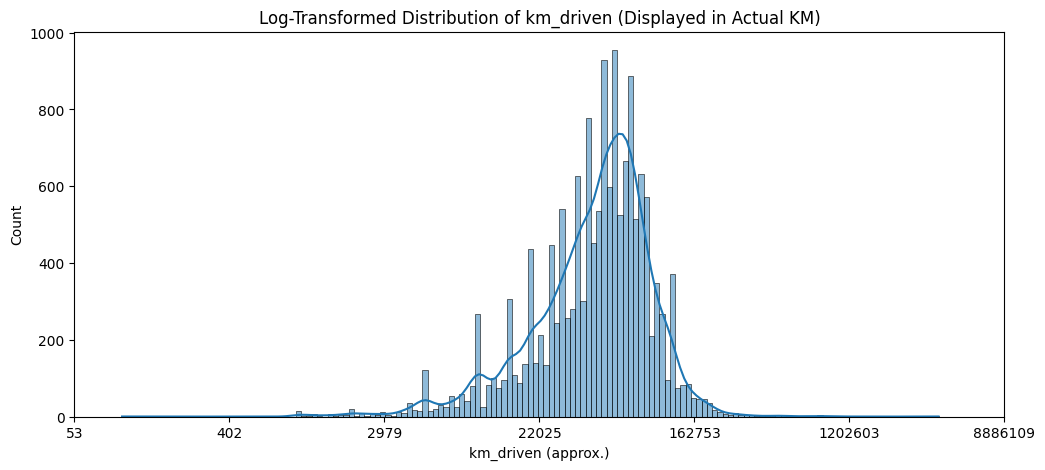

In [22]:
# Log transform km_driven
log_vals_km = np.log1p(df['km_driven'])

plt.figure(figsize=(12,5))
sns.histplot(log_vals_km, kde=True)

# Convert log ticks back to actual km values
ticks = plt.xticks()[0]
plt.xticks(ticks, [int(np.expm1(t)) for t in ticks])

plt.xlabel("km_driven (approx.)")
plt.title("Log-Transformed Distribution of km_driven (Displayed in Actual KM)")
plt.show()


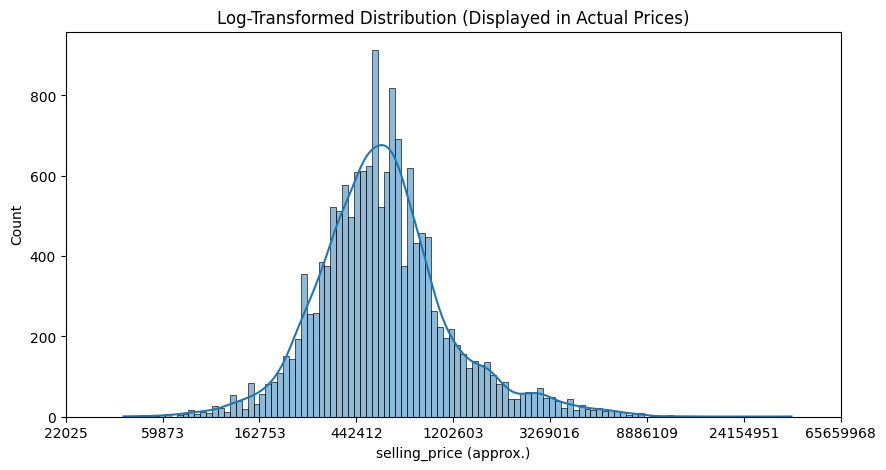

In [20]:
log_vals = np.log1p(df['selling_price'])
sns.histplot(log_vals, kde=True)

# Replace x-axis values with actual money values
ticks = plt.xticks()[0]
plt.xticks(ticks, [int(np.expm1(t)) for t in ticks])
plt.xlabel("selling_price (approx.)")

plt.title("Log-Transformed Distribution (Displayed in Actual Prices)")
plt.show()


Categorical Variables – Bar Charts

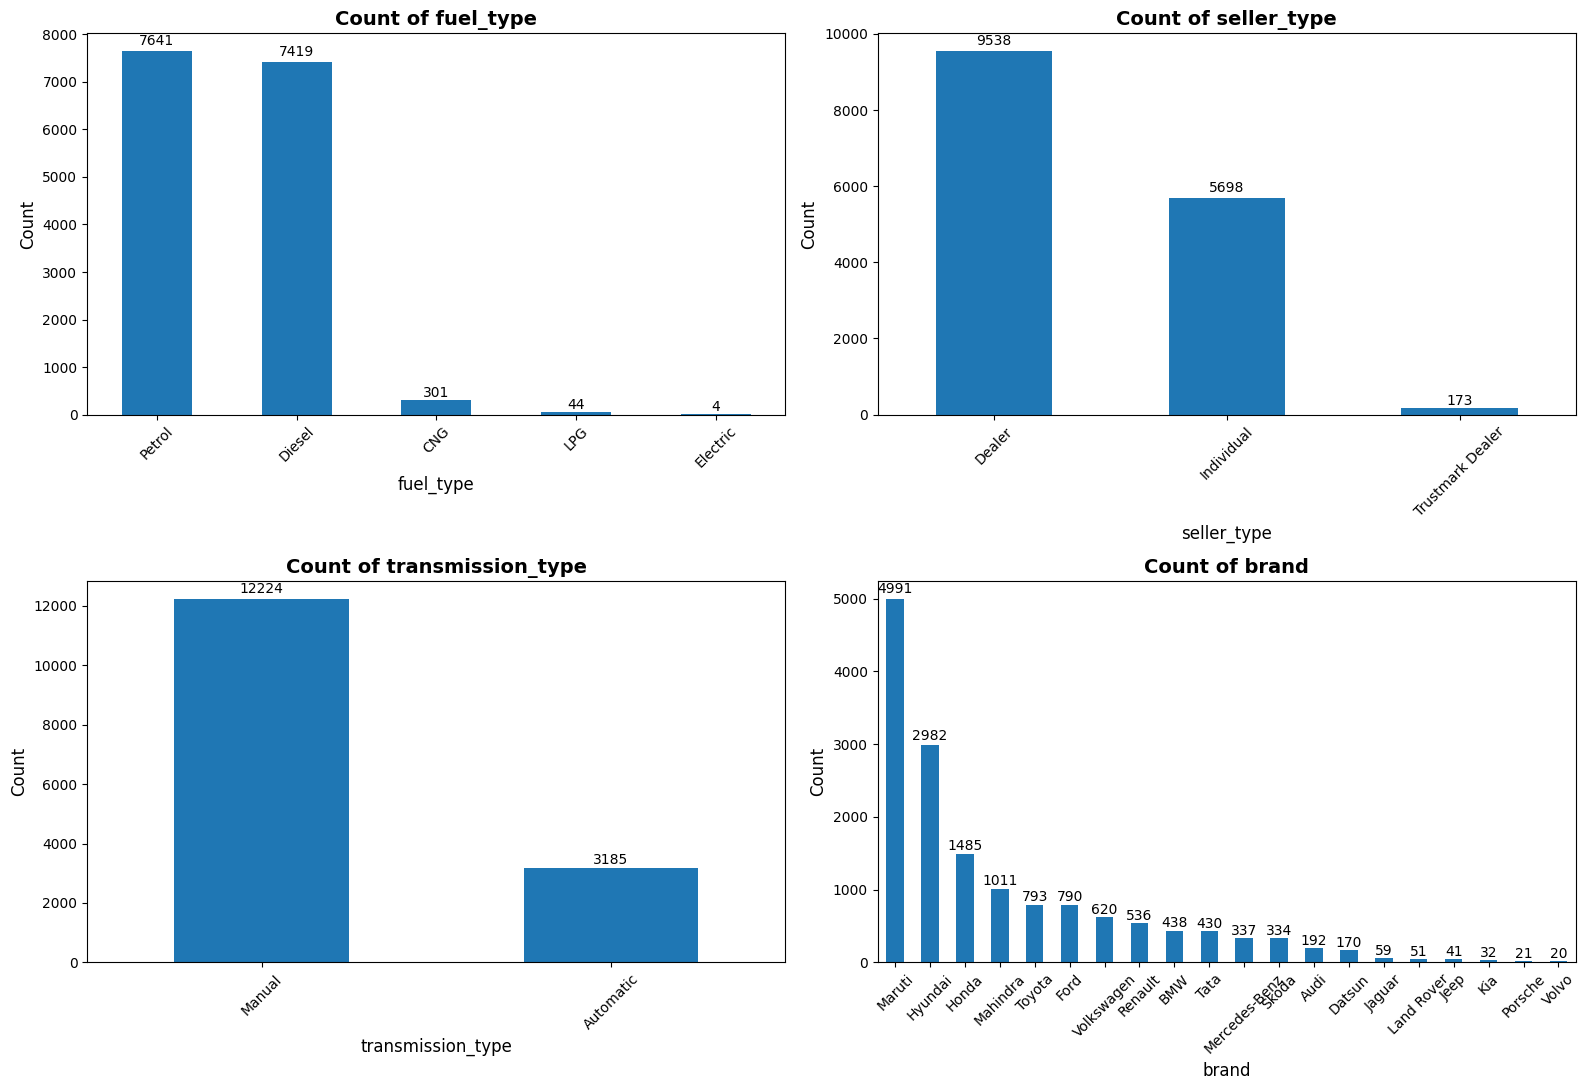

In [36]:
cat_cols = ['fuel_type', 'seller_type', 'transmission_type', 'brand']

plt.figure(figsize=(16, 11))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    counts = df[col].value_counts().head(20)
    bars = counts.plot(kind='bar')

    plt.title(f"Count of {col}", fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.xticks(rotation=45)

    for idx, value in enumerate(counts):
        plt.text(idx, value + (value * 0.01),str(value), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Bivariate Analysis

Price vs Year

In [45]:
df_plot = df.copy()

df_plot['selling_price'] = df_plot['selling_price'].clip(
    upper=df_plot['selling_price'].quantile(0.99))

df_plot['km_driven'] = df_plot['km_driven'].clip(
    upper=df_plot['km_driven'].quantile(0.99))

C:\Users\HP\AppData\Local\Temp\ipykernel_8536\3270364162.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(t):,}" for t in y_ticks])


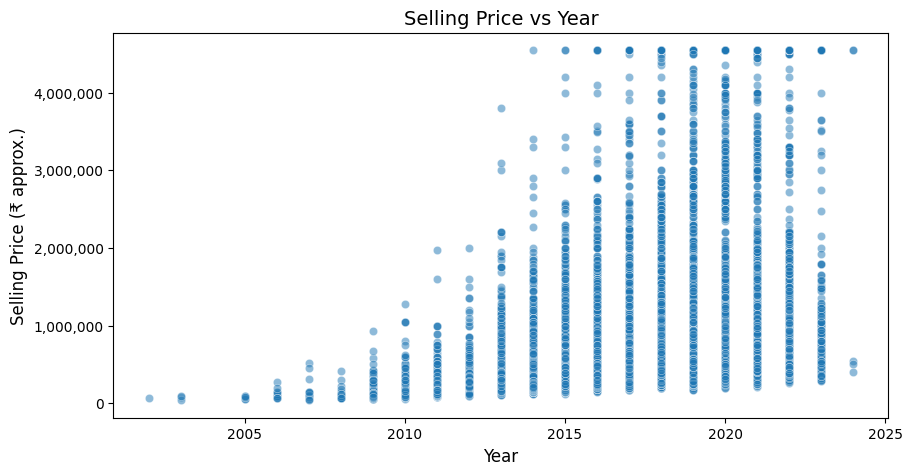

In [ ]:
ax = sns.scatterplot(data=df_plot, x='year', y='selling_price', alpha=0.5)
plt.title("Selling Price vs Year", fontsize=14)

y_ticks = ax.get_yticks()
ax.set_yticklabels([f"{int(t):,}" for t in y_ticks])

plt.xlabel("Year", fontsize=12)
plt.ylabel("Selling Price (₹ approx.)", fontsize=12)

plt.show()

Price vs Km Driven

In [37]:
df_plot = df.copy()

df_plot['selling_price'] = df_plot['selling_price'].clip(
    upper = df_plot['selling_price'].quantile(0.99))

df_plot['km_driven'] = df_plot['km_driven'].clip(
    upper = df_plot['km_driven'].quantile(0.99))

C:\Users\HP\AppData\Local\Temp\ipykernel_8536\137526254.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{int(t):,}" for t in x_ticks])
C:\Users\HP\AppData\Local\Temp\ipykernel_8536\137526254.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(t):,}" for t in y_ticks])


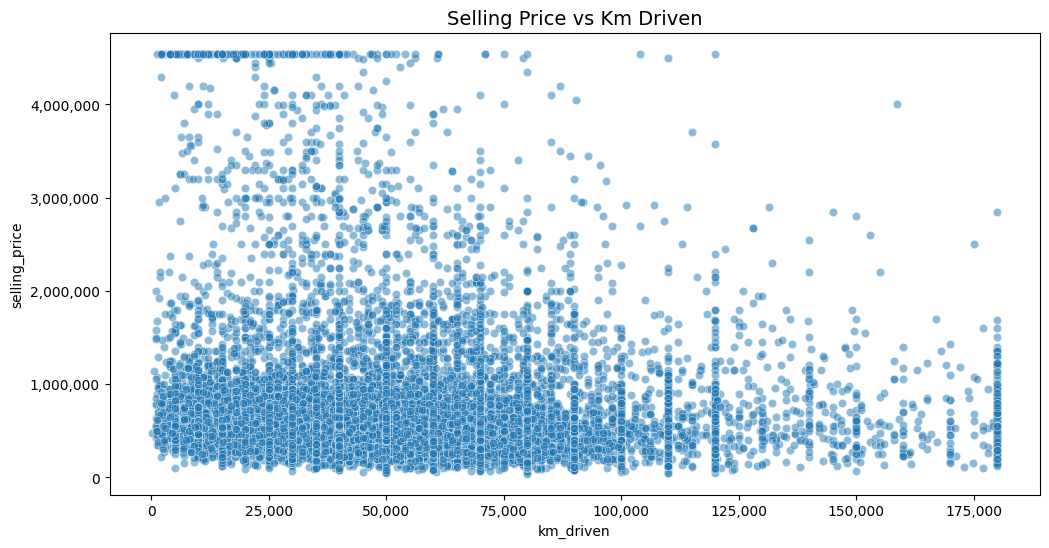

In [39]:
plt.figure(figsize=(12,6))
ax = sns.scatterplot(data=df_plot, x='km_driven', y='selling_price', alpha=0.5)
plt.title("Selling Price vs Km Driven", fontsize=14)

# Format X-axis & Y-axis ticks with commas (approx numbers)
x_ticks = ax.get_xticks()
ax.set_xticklabels([f"{int(t):,}" for t in x_ticks])

y_ticks = ax.get_yticks()
ax.set_yticklabels([f"{int(t):,}" for t in y_ticks])

plt.xlabel("km_driven")
plt.ylabel("selling_price")
plt.show()

Price by Fuel Type

C:\Users\HP\AppData\Local\Temp\ipykernel_8536\3556994539.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(t):,}" for t in y_ticks])


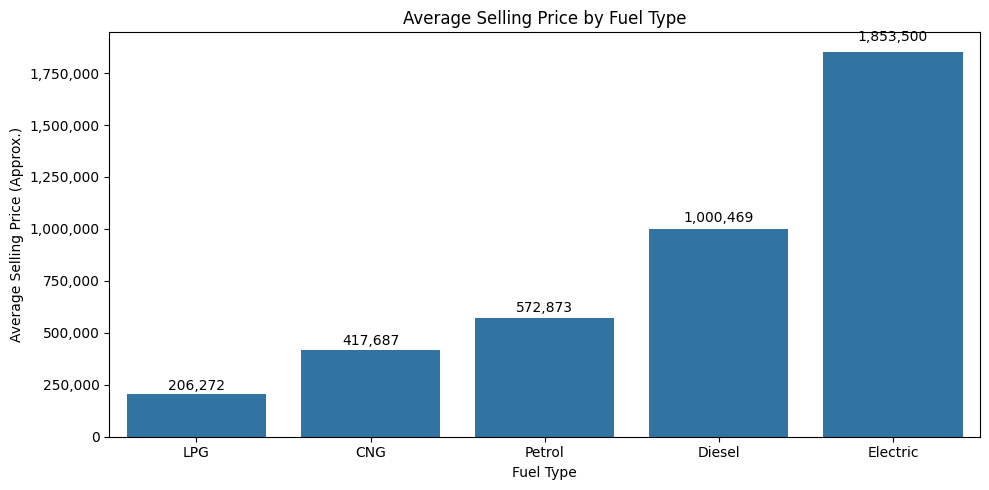

In [55]:
fuel_price = df.groupby("fuel_type")["selling_price"].mean().sort_values()

ax = sns.barplot(x=fuel_price.index, y=fuel_price.values)

plt.title("Average Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Selling Price (Approx.)")

y_ticks = ax.get_yticks()
ax.set_yticklabels([f"{int(t):,}" for t in y_ticks])

for i, v in enumerate(fuel_price.values):
    ax.text(i, v + (v * 0.02), f"{int(v):,}",ha='center', va='bottom')

plt.tight_layout()
plt.show()

Price by Seller Type

C:\Users\HP\AppData\Local\Temp\ipykernel_8536\2683157008.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(t):,}" for t in y_ticks])


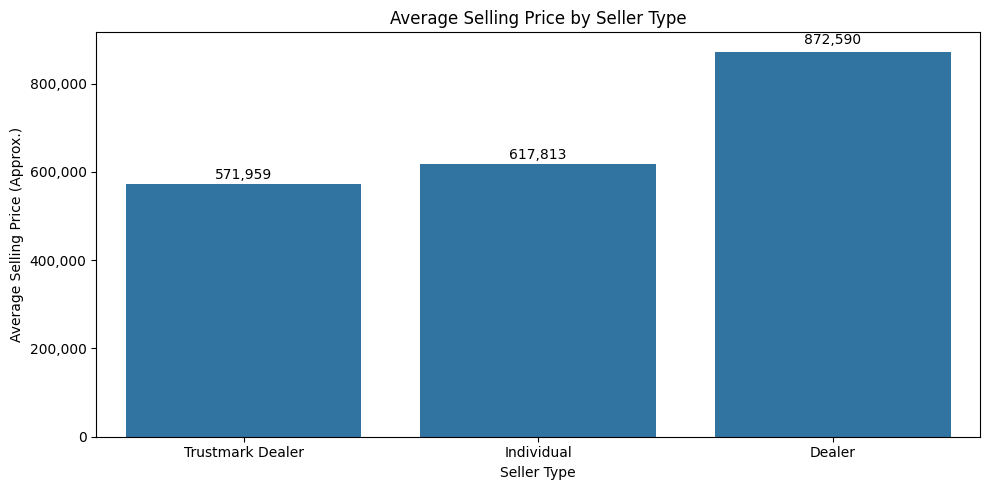

In [58]:
seller_price = df.groupby("seller_type")["selling_price"].mean().sort_values()
ax = sns.barplot(x=seller_price.index, y=seller_price.values)

plt.title("Average Selling Price by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Average Selling Price (Approx.)")

y_ticks = ax.get_yticks()
ax.set_yticklabels([f"{int(t):,}" for t in y_ticks])

# Add labels on bars
for i, v in enumerate(seller_price.values):
    ax.text(i, v + v*0.02, f"{int(v):,}", ha='center')

plt.tight_layout()
plt.show()

Price by Brand

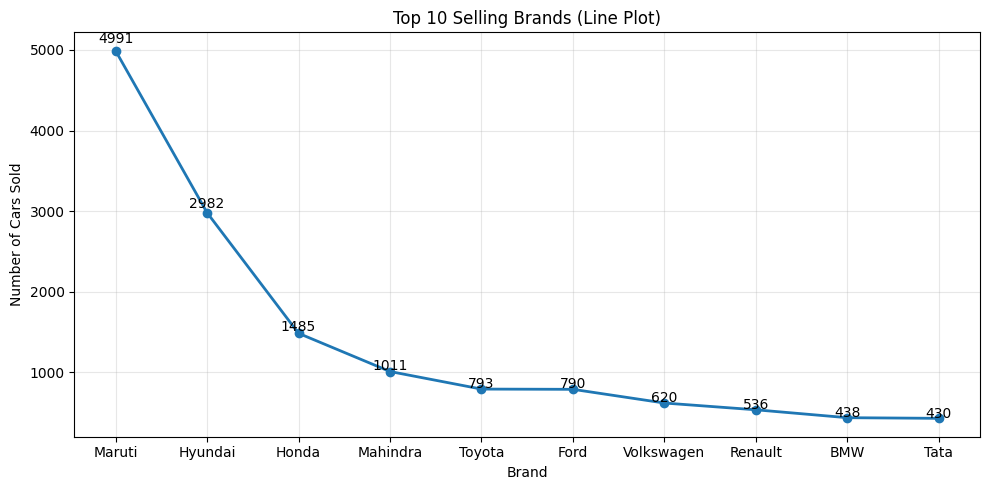

In [ ]:
plt.plot(top_selling.index, top_selling.values, marker='o', linewidth=2)

plt.title("Top 10 Selling Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Cars Sold")

# Add labels at each point
for i, v in enumerate(top_selling.values):
    plt.text(i, v + (v * 0.02), str(v), ha='center')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_8536\1129315226.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(t):,}" for t in y_ticks])


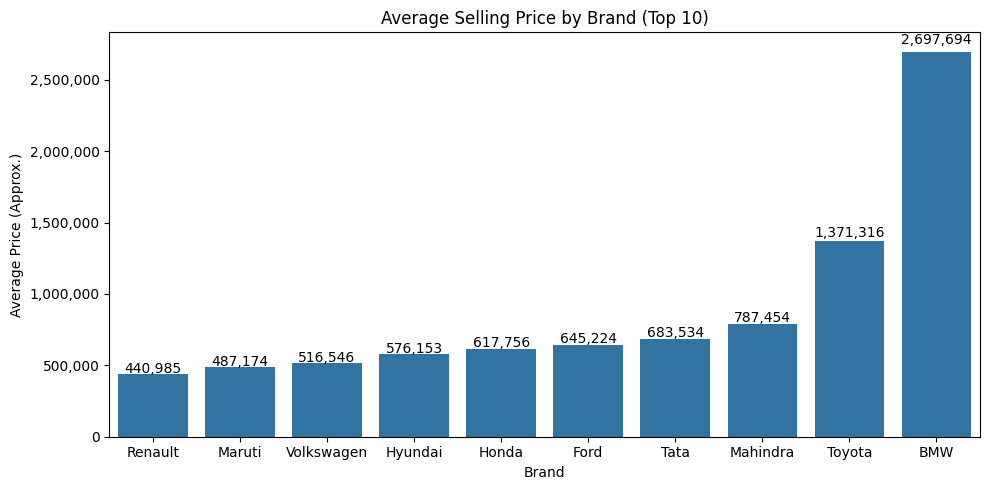

In [63]:
brand_avg = df_top_brands.groupby("brand")["selling_price"].mean().sort_values()

ax = sns.barplot(x=brand_avg.index, y=brand_avg.values)

plt.title("Average Selling Price by Brand (Top 10)")
y_ticks = ax.get_yticks()
ax.set_yticklabels([f"{int(t):,}" for t in y_ticks])

# Label on bars
for i, v in enumerate(brand_avg.values):
    ax.text(i, v + v*0.02, f"{int(v):,}", ha='center', fontsize=10)

plt.ylabel("Average Price (Approx.)")
plt.xlabel("Brand")
plt.tight_layout()
plt.show()


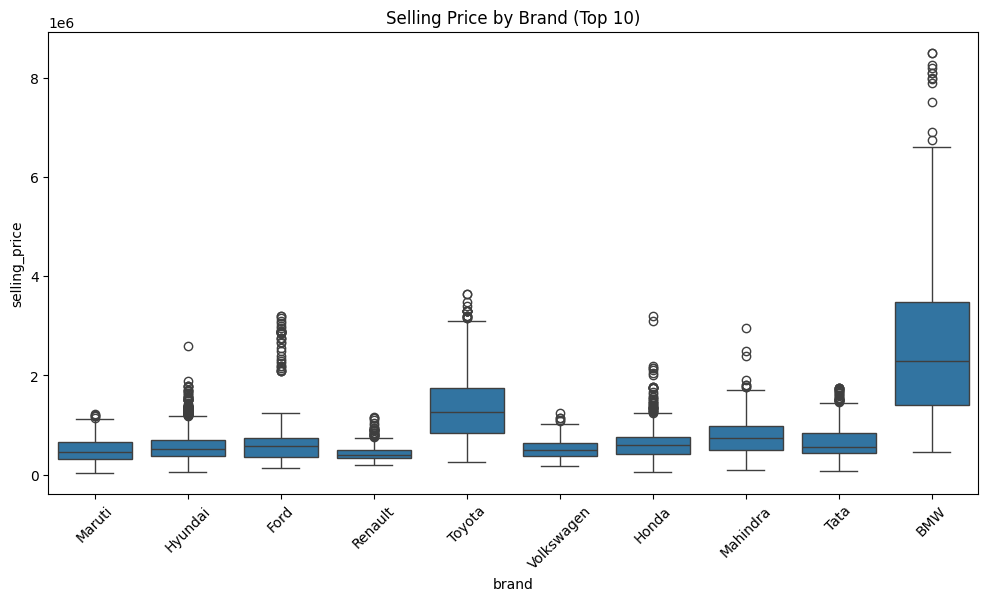

In [59]:
top_brands = df['brand'].value_counts().head(10).index
df_top_brands = df[df['brand'].isin(top_brands)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top_brands, x='brand', y='selling_price')
plt.title("Selling Price by Brand (Top 10)")
plt.xticks(rotation=45)
plt.show()

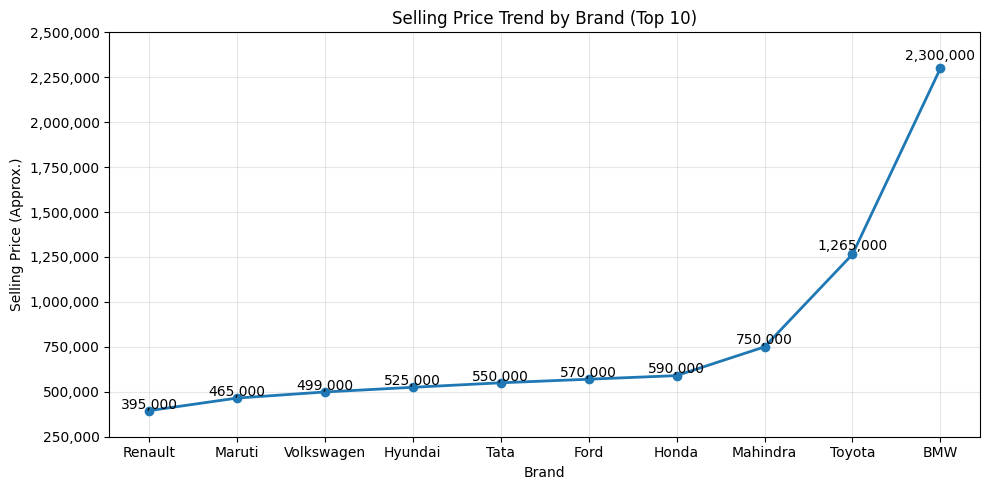

In [71]:
top_brands = df['brand'].value_counts().head(10).index
df_top_brands = df[df['brand'].isin(top_brands)]

brand_median = df_top_brands.groupby("brand")["selling_price"].median().sort_values()

plt.plot(brand_median.index, brand_median.values, marker='o', linewidth=2)

plt.title("Selling Price Trend by Brand (Top 10)")
plt.xlabel("Brand")
plt.ylabel("Selling Price (Approx.)")

# Format Y-axis numbers
y_ticks = plt.yticks()[0]
plt.yticks(y_ticks, [f"{int(t):,}" for t in y_ticks])

# Label each point
for i, v in enumerate(brand_median.values):
    plt.text(i, v + v*0.02, f"{int(v):,}", ha='center', fontsize=10)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Correlation Between Numeric Features


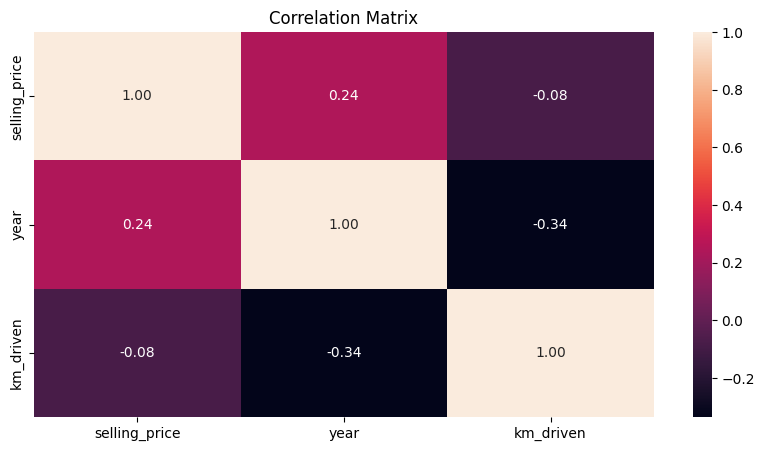

In [73]:
num_cols = ['selling_price', 'year', 'km_driven'] 
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### SALES ANALYSIS 

Basic Sales Overview

In [74]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print(df['selling_price'].astype(float).describe())

count      15409.00
mean      775002.91
std       894166.00
min        40000.00
25%       385000.00
50%       556000.00
75%       825000.00
max     39500000.00
Name: selling_price, dtype: float64


Extract Brand

In [75]:
df['brand'] = df['car_name'].str.split().str[0]
df['brand'].value_counts().head(10)

brand
Maruti        4991
Hyundai       2982
Honda         1485
Mahindra      1011
Toyota         793
Ford           790
Volkswagen     620
Renault        536
BMW            438
Tata           430
Name: count, dtype: int64

Total & Average Sales by Brand

In [76]:
brand_sales = df.groupby('brand').agg(
    total_cars = ('selling_price', 'count'),
    avg_price = ('selling_price', 'mean'),
    min_price = ('selling_price', 'min'),
    max_price = ('selling_price', 'max')
).sort_values('total_cars', ascending=False)

brand_sales.head(10)

,total_cars,avg_price,min_price,max_price
brand,,,,
Maruti,4991,487174.89,40000.00,1225000.00
Hyundai,2982,576153.92,60000.00,2600000.00
Honda,1485,617756.90,50000.00,3200000.00
Mahindra,1011,787455.00,100000.00,2950000.00
Toyota,793,1371316.52,265000.00,3650000.00
Ford,790,645224.05,130000.00,3200000.00
Volkswagen,620,516546.77,173000.00,1250000.00
Renault,536,440985.07,200000.00,1155000.00
BMW,438,2697694.06,465000.00,8500000.00


Sales by Year

In [78]:
year_sales = df.groupby('year').agg(
    total_cars = ('selling_price', 'count'),
    avg_price = ('selling_price', 'mean')
).sort_index()

year_sales.head()

,total_cars,avg_price
year,,
2002,1,70000.00
2003,3,73333.33
2005,5,74000.00
2006,11,125000.00
2007,17,156470.59


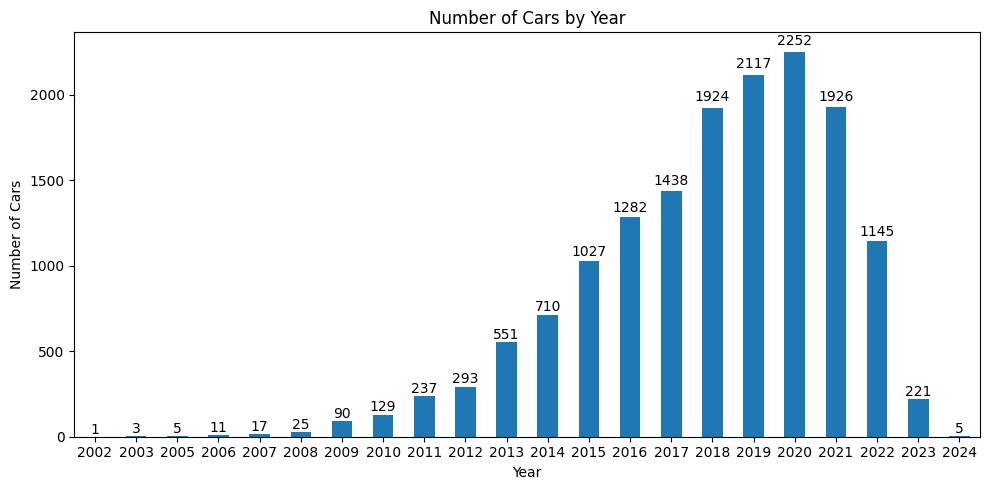

In [ ]:
ax = year_sales['total_cars'].plot(kind='bar')

plt.title("Number of Cars by Year")
plt.ylabel("Number of Cars")
plt.xlabel("Year")

for i, v in enumerate(year_sales['total_cars']):
    ax.text(i, v + (v * 0.01), str(v),ha='center', va='bottom')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Sales / Price by Fuel Type

In [82]:
fuel_sales = df.groupby('fuel_type').agg(
    total_cars=('selling_price', 'count'),
    avg_price=('selling_price', 'mean')
).sort_values('total_cars', ascending=False)

fuel_sales

,total_cars,avg_price
fuel_type,,
Petrol,7641,572873.17
Diesel,7419,1000469.34
CNG,301,417687.71
LPG,44,206272.73
Electric,4,1853500.00


Create Price Segments

In [83]:
# Use quantiles to define price segments
price_q = df['selling_price'].quantile([0.33, 0.66])
low_thr = price_q.iloc[0]
high_thr = price_q.iloc[1]

def price_segment(price):
    if price <= low_thr:
        return 'Low'
    elif price <= high_thr:
        return 'Medium'
    else:
        return 'High'

df['price_segment'] = df['selling_price'].apply(price_segment)

df['price_segment'].value_counts()

price_segment
Medium    5213
Low       5099
High      5097
Name: count, dtype: int64

In [84]:
segment_sales = df.groupby('price_segment').agg(
    total_cars = ('selling_price', 'count'),
    avg_price = ('selling_price', 'mean')
).sort_values('avg_price')

segment_sales

,total_cars,avg_price
price_segment,,
Low,5099,310306.11
Medium,5213,565448.88
High,5097,1454205.22


### SEGMENTATION

In [ ]:
features = df[['selling_price', 'year', 'km_driven']].copy()

# Optional: remove extreme outliers to get better clusters
features = features[
    (features['selling_price'] < features['selling_price'].quantile(0.99)) &
    (features['km_driven'] < features['km_driven'].quantile(0.99))]

features.describe()

,selling_price,year,km_driven
count,15090.00,15090.00,15090.00
mean,717895.22,2017.97,53374.19
std,595917.80,2.99,31277.51
min,40000.00,2002.00,100.00
25%,380000.00,2016.00,30000.00
50%,550000.00,2018.00,50000.00
75%,800000.00,2020.00,70000.00
max,4500000.00,2024.00,179000.00


In [86]:
from sklearn.preprocessing import StandardScaler

Scale the Features`

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

X_scaled[:5] 

array([[-1.00335153, -0.99419302,  2.13022101],
       [-0.28175158,  0.34291684, -1.06706995],
       [-0.84392828, -1.66274795,  0.21184643],
       [-0.82546875, -0.99419302, -0.52353049],
       [-0.2481888 ,  0.00863938, -0.74734085]])

Number of Clusters

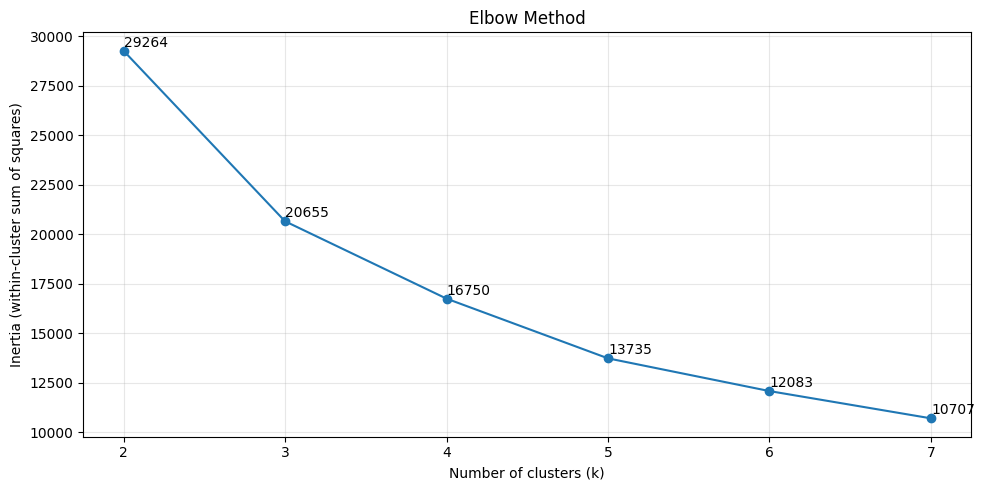

In [89]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')

plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method")
for i, v in zip(K_range, inertia):
    plt.text(i, v + 200, f"{int(v)}")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Fit KMeans Clustering

In [90]:
features = df[['km_driven', 'selling_price', 'vehicle_age']]

In [91]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [92]:
from sklearn.cluster import KMeans

k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

df['cluster'] = kmeans.fit_predict(X_scaled)

In [93]:
df_clust = df.copy()

In [94]:
df_clust['year'] = 2024 - df_clust['vehicle_age']

Numeric Summary by Cluster

In [95]:
cluster_profile = df_clust.groupby('cluster').agg(
    avg_price = ('selling_price', 'mean'),
    avg_year = ('year', 'mean'),
    avg_km = ('km_driven', 'mean'),
    count = ('selling_price', 'count')
).sort_values('avg_price')

cluster_profile

,avg_price,avg_year,avg_km,count
cluster,,,,
2,494262.37,2014.79,80929.90,5587
1,722195.56,2019.79,41001.80,9179
3,1225000.00,2019.00,3800000.00,1
0,3972457.94,2019.57,38507.89,642


In [96]:
fuel_cluster = pd.crosstab(df_clust['cluster'], df_clust['fuel_type'], normalize='index') * 100
fuel_cluster.round(1)

fuel_type,CNG,Diesel,Electric,LPG,Petrol
cluster,,,,,
0,0.00,84.90,0.00,0.00,15.10
1,2.30,42.10,0.00,0.00,55.60
2,1.70,53.90,0.00,0.80,43.60
3,0.00,100.00,0.00,0.00,0.00


In [97]:
seller_cluster = pd.crosstab(df_clust['cluster'], df_clust['seller_type'], normalize='index') * 100
seller_cluster.round(1)

seller_type,Dealer,Individual,Trustmark Dealer
cluster,,,
0,86.60,13.40,0.00
1,60.20,38.10,1.70
2,61.80,37.80,0.30
3,100.00,0.00,0.00


In [98]:
trans_cluster = pd.crosstab(df_clust['cluster'], df_clust['transmission_type'], normalize='index') * 100
trans_cluster.round(1)

transmission_type,Automatic,Manual
cluster,,
0,95.80,4.20
1,19.00,81.00
2,14.70,85.30
3,0.00,100.00


Visualize Clusters

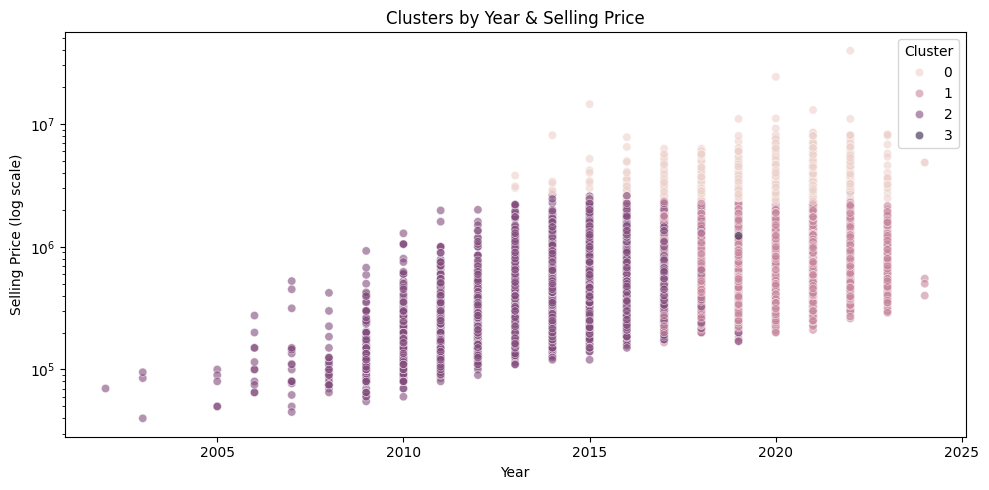

In [102]:
sns.scatterplot(data=df_clust, x='year', y='selling_price', hue='cluster', alpha=0.6)
plt.yscale("log")
plt.title("Clusters by Year & Selling Price")
plt.xlabel("Year")
plt.ylabel("Selling Price (log scale)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_8536\2723556738.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(t):,}" for t in y_ticks])


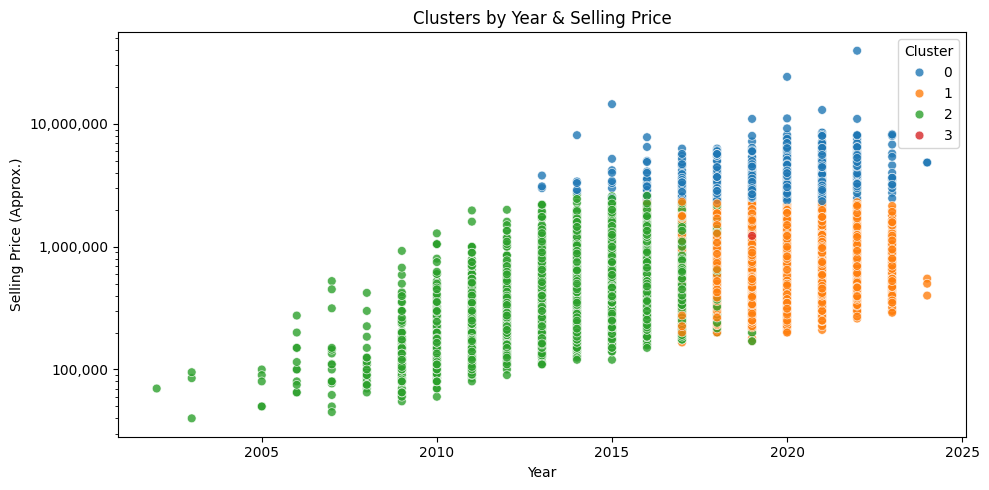

In [107]:
ax = sns.scatterplot(data=df_clust,x='year',y='selling_price',hue='cluster',palette='tab10',alpha=0.8,s=40)

plt.yscale("log")

plt.title("Clusters by Year & Selling Price")
plt.xlabel("Year")
plt.ylabel("Selling Price (Approx.)")
plt.legend(title="Cluster")

y_ticks = ax.get_yticks()
ax.set_yticklabels([f"{int(t):,}" for t in y_ticks])

plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_8536\3787601485.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(t):,}" for t in y_ticks])
C:\Users\HP\AppData\Local\Temp\ipykernel_8536\3787601485.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{int(t):,}" for t in x_ticks])


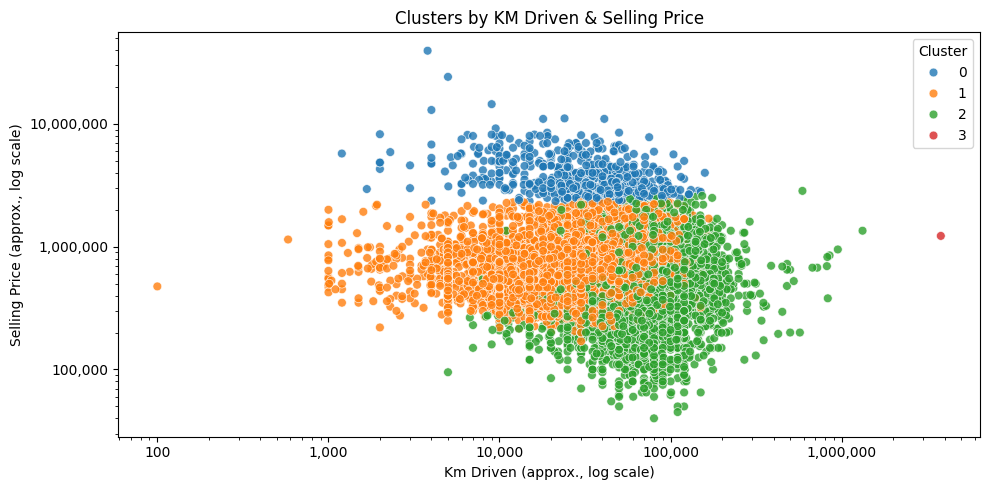

In [109]:
ax = sns.scatterplot(data=df_clust, x='km_driven',y='selling_price', hue='cluster',palette='tab10',alpha=0.8,s=40)

plt.xscale("log")
plt.yscale("log")

plt.title("Clusters by KM Driven & Selling Price")
plt.xlabel("Km Driven (approx., log scale)")
plt.ylabel("Selling Price (approx., log scale)")

plt.legend(title="Cluster")


y_ticks = ax.get_yticks()
ax.set_yticklabels([f"{int(t):,}" for t in y_ticks])

x_ticks = ax.get_xticks()
ax.set_xticklabels([f"{int(t):,}" for t in x_ticks])

plt.tight_layout()
plt.show()